# 2026 NBA Playoffs: Spurs vs. Knicks Win Prediction

**Project goal:** Build a machine learning model that predicts NBA game winners, then apply the trained model to the San Antonio Spurs vs. New York Knicks matchup.

This notebook uses historical NBA game and team box score data from Kaggle. The project follows this workflow:

1. Download and load the datasets.
2. Merge game-level and team-level data.
3. Clean the dataset and create a win/loss target.
4. Engineer pre-game style features such as rolling averages, rest days, and opponent comparison features.
5. Train and compare multiple models.
6. Use the best model, HistGradientBoosting, to predict Spurs vs. Knicks outcomes.

**Important modeling note:** To avoid data leakage, the final model does not use current-game box score columns such as `teamScore`, `opponentScore`, quarter points, or plus/minus directly as features. Instead, it uses rolling averages from previous games.

## 1. Install and import libraries

`kagglehub` is used to download the Kaggle dataset directly into the notebook environment.

In [28]:
# Install KaggleHub if needed
!pip install -q kagglehub

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

## 2. Download and load the Kaggle dataset

The dataset contains historical NBA games, team statistics, and player box scores. For this project, the two main files are:

- `TeamStatistics.csv`: one row per team per game
- `Games.csv`: one row per NBA game

Because `TeamStatistics.csv` has one row for each team, it usually has about twice as many rows as `Games.csv`.

In [30]:
# Download dataset from Kaggle
path = kagglehub.dataset_download(
    "eoinamoore/historical-nba-data-and-player-box-scores"
)

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'historical-nba-data-and-player-box-scores' dataset.
Path to dataset files: /kaggle/input/historical-nba-data-and-player-box-scores
['Players.csv', 'PlayerStatisticsExtended.csv', 'PlayByPlay.parquet', 'TeamStatistics.csv', 'PlayerStatistics.csv', 'Games.csv', 'LeagueSchedule25_26.csv', 'TeamHistories.csv', 'TeamStatisticsExtended.csv', 'LeagueSchedule24_25.csv']


In [31]:
# Load the main datasets
team_stats = pd.read_csv(os.path.join(path, "TeamStatistics.csv"))
games = pd.read_csv(os.path.join(path, "Games.csv"))

print("Team stats shape:", team_stats.shape)
print("Games shape:", games.shape)

Team stats shape: (146558, 59)
Games shape: (73278, 23)


/tmp/ipykernel_1324/774742010.py:3: DtypeWarning: Columns (12,14,15,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv(os.path.join(path, "Games.csv"))


In [32]:
display(team_stats.head())
display(games.head())

,gameId,gameDateTimeEst,teamCity,teamName,teamId,opponentTeamCity,opponentTeamName,opponentTeamId,home,win,...,gameLabel,gameSubLabel,seriesGameNumber,seed,reboundsTeam,turnoversTeam,ot1Points,ot2Points,otAllPoints,gameDate
0,42500404,2026-06-10 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,0,0.0,...,NBA Finals,Game 4,4.0,2.0,8.0,1.0,NaN,NaN,NaN,2026-06-10 20:30:00
1,42500404,2026-06-10 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,1,1.0,...,NBA Finals,Game 4,4.0,3.0,14.0,2.0,NaN,NaN,NaN,2026-06-10 20:30:00
2,42500403,2026-06-08 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,1,0.0,...,NBA Finals,Game 3,3.0,3.0,10.0,0.0,NaN,NaN,NaN,2026-06-08 20:30:00
3,42500403,2026-06-08 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,0,1.0,...,NBA Finals,Game 3,3.0,2.0,11.0,0.0,NaN,NaN,NaN,2026-06-08 20:30:00
4,42500402,2026-06-05 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,1,0.0,...,NBA Finals,Game 2,2.0,2.0,11.0,0.0,NaN,NaN,NaN,2026-06-05 20:30:00


,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500404,2026-06-10 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,107,106,...,NBA Finals,Game 4,Game 4,19812.0,30,Madison Square Garden,New York,NY,"Courtney Kirkland, Zach Zarba, James Williams,...",2026-06-10 20:30:00
1,42500403,2026-06-08 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,111,115,...,NBA Finals,Game 3,Game 3,19812.0,30,Madison Square Garden,New York,NY,"Marc Davis, John Goble, Curtis Blair, Nick Buc...",2026-06-08 20:30:00
2,42500402,2026-06-05 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,104,105,...,NBA Finals,Game 2,Game 2,19014.0,1000118,Frost Bank Center,San Antonio,TX,"Tony Brothers, Josh Tiven, Mitchell Ervin, Tyl...",2026-06-05 20:30:00
3,42500401,2026-06-03 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,95,105,...,NBA Finals,Game 1,Game 1,18835.0,1000118,Frost Bank Center,San Antonio,TX,"James Capers, JB DeRosa, Scott Foster, Sean Wr...",2026-06-03 20:30:00
4,42500317,2026-05-30 20:00:00,Oklahoma City,Thunder,1610612760,San Antonio,Spurs,1610612759,103,111,...,West Conf. Finals,Game 7,Game 7,18203.0,1000052,Paycom Center,Oklahoma City,OK,"Marc Davis, John Goble, Josh Tiven, Mitchell E...",2026-05-30 20:00:00


## 3. Merge team statistics with game information

The shared key between both datasets is `gameId`.  
The merged dataset should keep the same number of rows as `team_stats`, because each game has two team-stat rows.

In [33]:
# Check shared columns before merging
shared_columns = set(team_stats.columns).intersection(set(games.columns))
print("Shared columns:", shared_columns)

Shared columns: {'gameId', 'gameDate', 'gameLabel', 'seriesGameNumber', 'gameType', 'gameDateTimeEst', 'gameSubLabel'}


In [34]:
# Merge team-level stats with game-level info
merged_df = pd.merge(
    team_stats,
    games,
    on="gameId",
    how="left"
)

print("Team stats shape:", team_stats.shape)
print("Games shape:", games.shape)
print("Merged shape:", merged_df.shape)

# This should usually be True
print("Merged rows match team_stats rows:", team_stats.shape[0] == merged_df.shape[0])

Team stats shape: (146558, 59)
Games shape: (73278, 23)
Merged shape: (146558, 81)
Merged rows match team_stats rows: True


In [35]:
# Check missing values after merge
missing_values = merged_df.isna().sum().sort_values(ascending=False)
missing_values.head(30)

,0
coachId,146558
gameSubtype,146410
gameSubLabel_y,145904
ot2Points,145452
arenaState,143776
attendance,143774
officials,143758
arenaCity,143758
arenaName,143758
ot1Points,138742


## 4. Select useful columns for modeling

This step keeps the columns needed for analysis and modeling.  
Some columns are useful for creating rolling averages, but they should not be used directly as pre-game prediction features.

In [36]:
# Keep the columns needed for this project
model_df = merged_df[
    [
        "gameId",
        "gameDate_x",
        "teamCity",
        "teamName",
        "teamId",
        "opponentTeamCity",
        "opponentTeamName",
        "opponentTeamId",
        "home",
        "win",
        "teamScore",
        "opponentScore",
        "assists",
        "blocks",
        "steals",
        "fieldGoalsAttempted",
        "fieldGoalsMade",
        "fieldGoalsPercentage",
        "threePointersAttempted",
        "threePointersMade",
        "threePointersPercentage",
        "freeThrowsAttempted",
        "freeThrowsMade",
        "freeThrowsPercentage",
        "reboundsDefensive",
        "reboundsOffensive",
        "reboundsTotal",
        "foulsPersonal",
        "turnovers",
        "plusMinusPoints",
        "q1Points",
        "q2Points",
        "q3Points",
        "q4Points",
        "benchPoints",
        "biggestLead",
        "biggestScoringRun",
        "leadChanges",
        "pointsFastBreak",
        "pointsFromTurnovers",
        "pointsInThePaint",
        "pointsSecondChance",
        "seasonWins",
        "seasonLosses",
        "gameType_x",
        "gameLabel_x",
        "seriesGameNumber_x"
    ]
].copy()

# Rename columns from the team statistics side of the merge
model_df = model_df.rename(columns={
    "gameDate_x": "gameDate",
    "gameType_x": "gameType",
    "gameLabel_x": "gameLabel",
    "seriesGameNumber_x": "seriesGameNumber"
})

model_df.head()

,gameId,gameDate,teamCity,teamName,teamId,opponentTeamCity,opponentTeamName,opponentTeamId,home,win,...,leadChanges,pointsFastBreak,pointsFromTurnovers,pointsInThePaint,pointsSecondChance,seasonWins,seasonLosses,gameType,gameLabel,seriesGameNumber
0,42500404,2026-06-10 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,0,0.0,...,3.0,12.0,25.0,28.0,10.0,1.0,3.0,Playoffs,NBA Finals,4.0
1,42500404,2026-06-10 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,1,1.0,...,3.0,13.0,11.0,34.0,14.0,3.0,1.0,Playoffs,NBA Finals,4.0
2,42500403,2026-06-08 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,1,0.0,...,6.0,15.0,7.0,46.0,21.0,2.0,1.0,Playoffs,NBA Finals,3.0
3,42500403,2026-06-08 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,0,1.0,...,6.0,5.0,21.0,44.0,10.0,1.0,2.0,Playoffs,NBA Finals,3.0
4,42500402,2026-06-05 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,1,0.0,...,5.0,11.0,19.0,48.0,9.0,0.0,2.0,Playoffs,NBA Finals,2.0


## 5. Clean dates, create team labels, and create the target variable

The original `win` column can contain missing values or non-numeric values, so this notebook creates a clean binary target:

- `1` = team won the game
- `0` = team lost the game

In [37]:
# Clean invalid values
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Convert date
model_df["gameDate"] = pd.to_datetime(model_df["gameDate"])

# Create full team and opponent labels
model_df["team"] = model_df["teamCity"] + " " + model_df["teamName"]
model_df["opponent"] = model_df["opponentTeamCity"] + " " + model_df["opponentTeamName"]

# Keep only rows where scores are available
model_df = model_df.dropna(subset=["teamScore", "opponentScore"]).copy()

# Target variable
model_df["win_binary"] = (model_df["teamScore"] > model_df["opponentScore"]).astype(int)

# Point differential is used only to create rolling averages from previous games
model_df["point_diff"] = model_df["teamScore"] - model_df["opponentScore"]

model_df[["gameDate", "team", "opponent", "home", "teamScore", "opponentScore", "win_binary"]].head()

,gameDate,team,opponent,home,teamScore,opponentScore,win_binary
0,2026-06-10 20:30:00,San Antonio Spurs,New York Knicks,0,106,107,0
1,2026-06-10 20:30:00,New York Knicks,San Antonio Spurs,1,107,106,1
2,2026-06-08 20:30:00,New York Knicks,San Antonio Spurs,1,111,115,0
3,2026-06-08 20:30:00,San Antonio Spurs,New York Knicks,0,115,111,1
4,2026-06-05 20:30:00,San Antonio Spurs,New York Knicks,1,104,105,0


In [38]:
model_df["win_binary"].value_counts(normalize=True)

,proportion
win_binary,
0,0.500034
1,0.499966


## 6. Filter the 2025–2026 Spurs vs. Knicks matchup for later prediction

This subset is **not used to train the model**.  
It is saved for the final prediction section after all features are created.

In [39]:
season_2026 = model_df[
    (model_df["gameDate"] >= "2025-10-01") &
    (model_df["gameDate"] <= "2026-06-30")
].copy()

spurs_vs_knicks_preview = season_2026[
    (
        (season_2026["team"].isin(["San Antonio Spurs", "New York Knicks"])) &
        (season_2026["opponent"].isin(["San Antonio Spurs", "New York Knicks"]))
    )
].copy()

spurs_vs_knicks_preview[
    [
        "gameDate",
        "team",
        "opponent",
        "home",
        "teamScore",
        "opponentScore",
        "win_binary",
        "gameType",
        "gameLabel",
        "seriesGameNumber"
    ]
].sort_values("gameDate")

,gameDate,team,opponent,home,teamScore,opponentScore,win_binary,gameType,gameLabel,seriesGameNumber
1882,2025-12-16 20:30:00,San Antonio Spurs,New York Knicks,0,113,124,0,Emirates NBA Cup,Emirates NBA Cup,NaN
1883,2025-12-16 20:30:00,New York Knicks,San Antonio Spurs,1,124,113,1,Emirates NBA Cup,Emirates NBA Cup,NaN
1672,2025-12-31 19:00:00,New York Knicks,San Antonio Spurs,0,132,134,0,Regular Season,NaN,NaN
1673,2025-12-31 19:00:00,San Antonio Spurs,New York Knicks,1,134,132,1,Regular Season,NaN,NaN
848,2026-03-01 13:00:00,San Antonio Spurs,New York Knicks,0,89,114,0,Regular Season,NaN,NaN
849,2026-03-01 13:00:00,New York Knicks,San Antonio Spurs,1,114,89,1,Regular Season,NaN,NaN
6,2026-06-03 20:30:00,New York Knicks,San Antonio Spurs,0,105,95,1,Playoffs,NBA Finals,1.0
7,2026-06-03 20:30:00,San Antonio Spurs,New York Knicks,1,95,105,0,Playoffs,NBA Finals,1.0
4,2026-06-05 20:30:00,San Antonio Spurs,New York Knicks,1,104,105,0,Playoffs,NBA Finals,2.0
5,2026-06-05 20:30:00,New York Knicks,San Antonio Spurs,0,105,104,1,Playoffs,NBA Finals,2.0


## 7. Feature engineering

The model should predict games using information that would be known before the game.  
To do that, this section creates:

- Season win percentage
- Rest days
- Back-to-back indicator
- Rolling 5-game averages
- Rolling 10-game averages
- Opponent rolling features
- Difference features comparing each team to its opponent

### 7.1 Season win percentage, rest days, and back-to-back games

In [40]:
# Sort data before creating time-based features
model_df = model_df.sort_values(["team", "gameDate"]).copy()

# Season win percentage
model_df["season_win_pct"] = (
    model_df["seasonWins"] /
    (model_df["seasonWins"] + model_df["seasonLosses"])
)

# Previous game date by team
model_df["previous_game_date"] = model_df.groupby("team")["gameDate"].shift(1)

# Rest days
model_df["rest_days"] = (model_df["gameDate"] - model_df["previous_game_date"]).dt.days

# Cap rest days at 7 so offseason or long gaps do not dominate the model
model_df["rest_days"] = model_df["rest_days"].clip(0, 7)

# Back-to-back indicator
model_df["back_to_back"] = (model_df["rest_days"] <= 1).astype(int)

### 7.2 Rolling averages from previous games

The `shift(1)` is important because it prevents the model from using the current game's final stats.

In [41]:
rolling_cols = [
    "teamScore",
    "opponentScore",
    "assists",
    "reboundsTotal",
    "turnovers",
    "fieldGoalsPercentage",
    "threePointersPercentage",
    "freeThrowsPercentage",
    "steals",
    "blocks",
    "point_diff",
    "win_binary"
]

for window in [5, 10]:
    for col in rolling_cols:
        model_df[f"{col}_last{window}"] = (
            model_df
            .groupby("team")[col]
            .transform(lambda x: x.shift(1).rolling(window).mean())
        )

### 7.3 Add opponent season record features

Each row represents one team. This step attaches the opponent's season record from the matching opponent row in the same game.

In [42]:
opponent_record = model_df[
    ["gameId", "team", "seasonWins", "seasonLosses", "season_win_pct"]
].copy()

opponent_record = opponent_record.rename(columns={
    "team": "opponent",
    "seasonWins": "opponent_seasonWins",
    "seasonLosses": "opponent_seasonLosses",
    "season_win_pct": "opponent_season_win_pct"
})

model_df = model_df.merge(
    opponent_record,
    on=["gameId", "opponent"],
    how="left"
)

model_df["season_win_pct_diff"] = (
    model_df["season_win_pct"] - model_df["opponent_season_win_pct"]
)

model_df["season_wins_diff"] = (
    model_df["seasonWins"] - model_df["opponent_seasonWins"]
)

### 7.4 Add opponent rolling features

This step lets the model compare a team's recent form against its opponent's recent form.

In [43]:
def add_opponent_rolling_features(df, window):
    '''
    Add opponent rolling features for a given rolling window.
    '''
    opponent_cols = [
        "point_diff",
        "win_binary",
        "teamScore",
        "reboundsTotal",
        "turnovers",
        "threePointersPercentage"
    ]

    rolling_feature_cols = [f"{col}_last{window}" for col in opponent_cols]

    opponent_rolling = df[["gameId", "team"] + rolling_feature_cols].copy()

    rename_map = {"team": "opponent"}
    for col in opponent_cols:
        rename_map[f"{col}_last{window}"] = f"opponent_{col}_last{window}"

    opponent_rolling = opponent_rolling.rename(columns=rename_map)

    df = df.merge(
        opponent_rolling,
        on=["gameId", "opponent"],
        how="left"
    )

    return df

model_df = add_opponent_rolling_features(model_df, 5)
model_df = add_opponent_rolling_features(model_df, 10)

### 7.5 Create matchup difference features

Difference features are often more useful than raw team features because they directly compare the team to the opponent.

In [44]:
for window in [5, 10]:
    model_df[f"win_pct_last{window}_diff"] = (
        model_df[f"win_binary_last{window}"] - model_df[f"opponent_win_binary_last{window}"]
    )

    model_df[f"point_diff_last{window}_diff"] = (
        model_df[f"point_diff_last{window}"] - model_df[f"opponent_point_diff_last{window}"]
    )

    model_df[f"scoring_last{window}_diff"] = (
        model_df[f"teamScore_last{window}"] - model_df[f"opponent_teamScore_last{window}"]
    )

    model_df[f"rebounds_last{window}_diff"] = (
        model_df[f"reboundsTotal_last{window}"] - model_df[f"opponent_reboundsTotal_last{window}"]
    )

    model_df[f"turnovers_last{window}_diff"] = (
        model_df[f"turnovers_last{window}"] - model_df[f"opponent_turnovers_last{window}"]
    )

    model_df[f"three_point_pct_last{window}_diff"] = (
        model_df[f"threePointersPercentage_last{window}"] -
        model_df[f"opponent_threePointersPercentage_last{window}"]
    )

## 8. Prepare the final modeling dataset

These are the final features used by the models.

The target variable is `win_binary`.

In [45]:
features = [
    "home",
    "seasonWins",
    "seasonLosses",
    "season_win_pct",
    "opponent_season_win_pct",
    "season_win_pct_diff",
    "season_wins_diff",
    "rest_days",
    "back_to_back",

    "win_binary_last5",
    "point_diff_last5",
    "opponent_win_binary_last5",
    "opponent_point_diff_last5",
    "win_pct_last5_diff",
    "point_diff_last5_diff",
    "scoring_last5_diff",
    "rebounds_last5_diff",
    "turnovers_last5_diff",
    "three_point_pct_last5_diff",

    "win_binary_last10",
    "point_diff_last10",
    "opponent_win_binary_last10",
    "opponent_point_diff_last10",
    "win_pct_last10_diff",
    "point_diff_last10_diff",
    "scoring_last10_diff",
    "rebounds_last10_diff",
    "turnovers_last10_diff",
    "three_point_pct_last10_diff"
]

model_data = model_df.dropna(subset=features + ["win_binary"]).copy()

X = model_data[features]
y = model_data["win_binary"]

print("Modeling dataset shape:", model_data.shape)
print("Number of features:", len(features))

Modeling dataset shape: (138052, 108)
Number of features: 29


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 110441
Testing rows: 27611


## 9. Train and compare models

This section compares four models:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. HistGradientBoosting

The goal is to see which model gives the best accuracy while still avoiding obvious data leakage.

In [47]:
model_results = []

def evaluate_model(model, model_name):
    '''
    Fit a model, evaluate accuracy, and store results.
    '''
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy
    })

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, predictions))

    return model, predictions

# Logistic Regression
log_model, log_predictions = evaluate_model(
    LogisticRegression(max_iter=1000),
    "Logistic Regression"
)

# Random Forest
rf_model, rf_predictions = evaluate_model(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "Random Forest"
)

# Gradient Boosting
gb_model, gb_predictions = evaluate_model(
    GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=8,
        random_state=42
    ),
    "Gradient Boosting"
)

# HistGradientBoosting
hist_model, hist_predictions = evaluate_model(
    HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        random_state=42
    ),
    "HistGradientBoosting"
)

Logistic Regression Accuracy: 0.7143
              precision    recall  f1-score   support

           0       0.71      0.72      0.72     13806
           1       0.72      0.71      0.71     13805

    accuracy                           0.71     27611
   macro avg       0.71      0.71      0.71     27611
weighted avg       0.71      0.71      0.71     27611

Random Forest Accuracy: 0.7234
              precision    recall  f1-score   support

           0       0.72      0.72      0.72     13806
           1       0.72      0.73      0.72     13805

    accuracy                           0.72     27611
   macro avg       0.72      0.72      0.72     27611
weighted avg       0.72      0.72      0.72     27611

Gradient Boosting Accuracy: 0.7138
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     13806
           1       0.71      0.71      0.71     13805

    accuracy                           0.71     27611
   macro avg       0.71  

In [48]:
results_df = pd.DataFrame(model_results).sort_values("Accuracy", ascending=False)
results_df

,Model,Accuracy
3,HistGradientBoosting,0.728550
1,Random Forest,0.723444
0,Logistic Regression,0.714281
2,Gradient Boosting,0.713846


## 10. Evaluate the best model

HistGradientBoosting was the best-performing model in this version of the notebook.

The confusion matrix below shows how often the model correctly predicted wins and losses.

In [49]:
cm = confusion_matrix(y_test, hist_predictions)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Loss", "Actual Win"],
    columns=["Predicted Loss", "Predicted Win"]
)

cm_df

,Predicted Loss,Predicted Win
Actual Loss,10065,3741
Actual Win,3754,10051


In [50]:
# Optional: permutation importance for HistGradientBoosting
# This can take a little time, but it helps explain which features influenced the model.

perm_importance = permutation_importance(
    hist_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy"
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
5,season_win_pct_diff,0.168245
0,home,0.049574
13,win_pct_last5_diff,0.010293
1,seasonWins,0.008982
2,seasonLosses,0.008873
23,win_pct_last10_diff,0.006215
4,opponent_season_win_pct,0.002608
3,season_win_pct,0.000529
6,season_wins_diff,0.000406
28,three_point_pct_last10_diff,0.000391


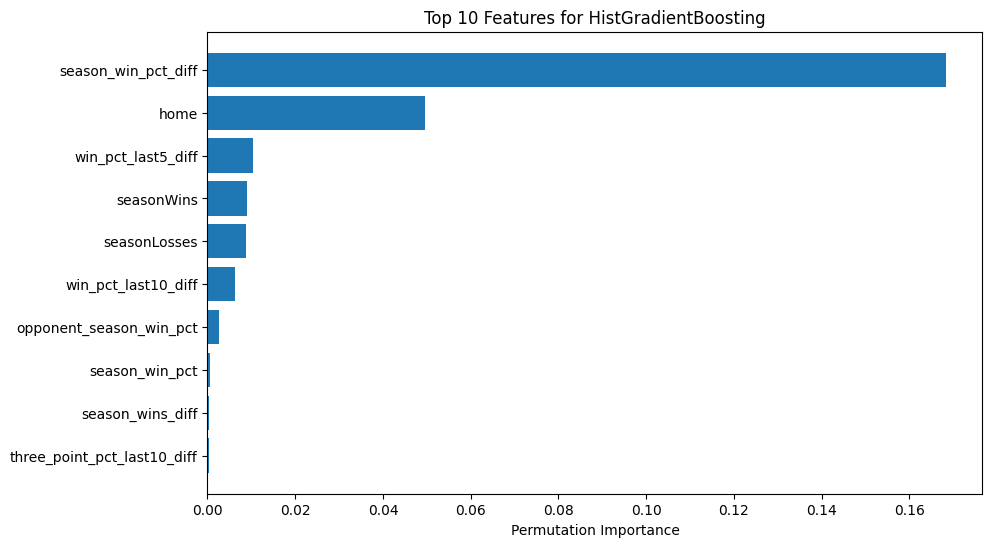

In [51]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Top 10 Features for HistGradientBoosting")
plt.show()

## 11. Apply the best model to Spurs vs. Knicks

Now that the final model has been trained, recreate the Spurs vs. Knicks subset from the fully engineered `model_df`.

This is important because creating `spurs_vs_knicks` too early can cause a `KeyError` if the engineered features are missing.

In [52]:
# Recreate Spurs vs Knicks after feature engineering is complete
spurs_vs_knicks = model_df[
    (
        (model_df["gameDate"] >= "2025-10-01") &
        (model_df["gameDate"] <= "2026-06-30") &
        (model_df["team"].isin(["San Antonio Spurs", "New York Knicks"])) &
        (model_df["opponent"].isin(["San Antonio Spurs", "New York Knicks"]))
    )
].copy()

# Check if any features are missing
missing_features = [col for col in features if col not in spurs_vs_knicks.columns]
print("Missing features:", missing_features)

spurs_vs_knicks[
    [
        "gameDate",
        "team",
        "opponent",
        "home",
        "teamScore",
        "opponentScore",
        "win_binary",
        "gameType",
        "gameLabel",
        "seriesGameNumber"
    ]
].sort_values("gameDate")

Missing features: []


,gameDate,team,opponent,home,teamScore,opponentScore,win_binary,gameType,gameLabel,seriesGameNumber
96753,2025-12-16 20:30:00,New York Knicks,San Antonio Spurs,1,124,113,1,Emirates NBA Cup,Emirates NBA Cup,NaN
127197,2025-12-16 20:30:00,San Antonio Spurs,New York Knicks,0,113,124,0,Emirates NBA Cup,Emirates NBA Cup,NaN
96761,2025-12-31 19:00:00,New York Knicks,San Antonio Spurs,0,132,134,0,Regular Season,NaN,NaN
127205,2025-12-31 19:00:00,San Antonio Spurs,New York Knicks,1,134,132,1,Regular Season,NaN,NaN
96789,2026-03-01 13:00:00,New York Knicks,San Antonio Spurs,1,114,89,1,Regular Season,NaN,NaN
127232,2026-03-01 13:00:00,San Antonio Spurs,New York Knicks,0,89,114,0,Regular Season,NaN,NaN
96825,2026-06-03 20:30:00,New York Knicks,San Antonio Spurs,0,105,95,1,Playoffs,NBA Finals,1.0
127273,2026-06-03 20:30:00,San Antonio Spurs,New York Knicks,1,95,105,0,Playoffs,NBA Finals,1.0
96826,2026-06-05 20:30:00,New York Knicks,San Antonio Spurs,0,105,104,1,Playoffs,NBA Finals,2.0
127274,2026-06-05 20:30:00,San Antonio Spurs,New York Knicks,1,104,105,0,Playoffs,NBA Finals,2.0


In [53]:
# Drop rows that do not have all model features
spurs_knicks_data = spurs_vs_knicks.dropna(subset=features).copy()

X_spurs_knicks = spurs_knicks_data[features]

# Predict win/loss and win probability
spurs_knicks_data["predicted_win"] = hist_model.predict(X_spurs_knicks)
spurs_knicks_data["win_probability"] = hist_model.predict_proba(X_spurs_knicks)[:, 1]
spurs_knicks_data["win_probability_percent"] = (
    spurs_knicks_data["win_probability"] * 100
).round(2)

spurs_knicks_data[
    [
        "gameDate",
        "team",
        "opponent",
        "home",
        "teamScore",
        "opponentScore",
        "win_binary",
        "predicted_win",
        "win_probability_percent"
    ]
].sort_values(["gameDate", "team"])

,gameDate,team,opponent,home,teamScore,opponentScore,win_binary,predicted_win,win_probability_percent
96753,2025-12-16 20:30:00,New York Knicks,San Antonio Spurs,1,124,113,1,1,99.91
127197,2025-12-16 20:30:00,San Antonio Spurs,New York Knicks,0,113,124,0,0,0.21
96761,2025-12-31 19:00:00,New York Knicks,San Antonio Spurs,0,132,134,0,0,26.65
127205,2025-12-31 19:00:00,San Antonio Spurs,New York Knicks,1,134,132,1,1,76.82
96789,2026-03-01 13:00:00,New York Knicks,San Antonio Spurs,1,114,89,1,1,58.06
127232,2026-03-01 13:00:00,San Antonio Spurs,New York Knicks,0,89,114,0,0,41.89
96825,2026-06-03 20:30:00,New York Knicks,San Antonio Spurs,0,105,95,1,1,99.91
127273,2026-06-03 20:30:00,San Antonio Spurs,New York Knicks,1,95,105,0,0,0.25
96826,2026-06-05 20:30:00,New York Knicks,San Antonio Spurs,0,105,104,1,1,99.91
127274,2026-06-05 20:30:00,San Antonio Spurs,New York Knicks,1,104,105,0,0,0.25


## 12. Choose the predicted winner for each Spurs vs. Knicks game

Because the dataset has two rows per game, one for each team, this step keeps the row with the higher win probability.

In [54]:
predicted_game_winners = (
    spurs_knicks_data
    .sort_values(["gameId", "win_probability"], ascending=[True, False])
    .groupby("gameId")
    .head(1)
    .copy()
)

summary_table = predicted_game_winners[
    [
        "gameDate",
        "team",
        "opponent",
        "home",
        "win_probability_percent"
    ]
].copy()

summary_table = summary_table.rename(columns={
    "team": "Predicted Winner",
    "opponent": "Opponent",
    "home": "Home Game",
    "win_probability_percent": "Win Probability (%)"
})

summary_table.sort_values("gameDate")

,gameDate,Predicted Winner,Opponent,Home Game,Win Probability (%)
96753,2025-12-16 20:30:00,New York Knicks,San Antonio Spurs,1,99.91
127205,2025-12-31 19:00:00,San Antonio Spurs,New York Knicks,1,76.82
96789,2026-03-01 13:00:00,New York Knicks,San Antonio Spurs,1,58.06
96825,2026-06-03 20:30:00,New York Knicks,San Antonio Spurs,0,99.91
96826,2026-06-05 20:30:00,New York Knicks,San Antonio Spurs,0,99.91
127275,2026-06-08 20:30:00,San Antonio Spurs,New York Knicks,0,63.68
96828,2026-06-10 20:30:00,New York Knicks,San Antonio Spurs,1,89.11


## 13. Finals winner interpretation

The model can predict Spurs vs. Knicks rows that exist in the dataset.  
However, if the Kaggle dataset only contains completed games, it cannot automatically predict future scheduled games unless those future rows are manually added with the same engineered features.

Use this section to combine:

1. The model's predicted winners for available Spurs vs. Knicks games.
2. The current Finals series score.
3. A clear written conclusion.

In [55]:
# Model-predicted winners for available Spurs vs Knicks rows
available_prediction_counts = (
    predicted_game_winners["team"]
    .value_counts()
    .rename_axis("Team")
    .reset_index(name="Predicted wins in available matchup rows")
)

display(available_prediction_counts)

# Update these values based on the latest known Finals series score
knicks_current_wins = 3
spurs_current_wins = 1

print("Current series score entered:")
print(f"New York Knicks: {knicks_current_wins}")
print(f"San Antonio Spurs: {spurs_current_wins}")

if knicks_current_wins >= 4:
    print("Finals Winner: New York Knicks")
elif spurs_current_wins >= 4:
    print("Finals Winner: San Antonio Spurs")
elif knicks_current_wins == 3:
    print("Projection: New York Knicks are favored because they need only one more win.")
elif spurs_current_wins == 3:
    print("Projection: San Antonio Spurs are favored because they need only one more win.")
else:
    print("Projection: Series is still open. Use the game-level prediction table above to discuss likely outcomes.")

,Team,Predicted wins in available matchup rows
0,New York Knicks,5
1,San Antonio Spurs,2


Current series score entered:
New York Knicks: 3
San Antonio Spurs: 1
Projection: New York Knicks are favored because they need only one more win.


### Optional next step: manually predict a future game

To predict a future Game 5, Game 6, or Game 7, you would need to create a new row with the same final `features` columns used by the model.  
For a beginner project, it is acceptable to state that the model predicts available matchup rows and that the series-score context favors the team that is closest to four wins.

## 14. Project summary

The final notebook shows a complete prediction workflow:

- The baseline idea was to predict game winners using simple pre-game features.
- The model improved by adding rolling averages, rest days, and opponent comparison features.
- HistGradientBoosting achieved the strongest performance among the tested models.
- The final trained model was then applied to the Spurs vs. Knicks matchup.

A strong final explanation for this project:

> I trained several machine learning models on historical NBA games using pre-game style features such as home-court advantage, season record, rest days, recent team performance, and opponent comparison features. The HistGradientBoosting model performed best, reaching about 72% accuracy. I then applied the model to the Spurs vs. Knicks Finals matchup to estimate game-level win probabilities and project the likely Finals winner.